# 📊 HTR Experiment Notebook for Thesis (Kaggle Compatible)

**Systematic experiments untuk 7 thesis tables:**
- Table 1: CNN Backbone Configuration
- Table 2: RNN/Sequence Encoding Performance
- Table 3: Data Augmentation Effect
- Table 4: Pretraining Strategy
- Table 5: Hyperparameter Tuning
- Table 6: Case & Punctuation Effect
- Table 7: State-of-the-Art Comparison

**Kompatibel dengan:**
- ✅ Kaggle Notebook (GPU P100/T4)
- ✅ Local Windows (dengan `num_workers=0`)

**Fitur:**
- Auto-detect Kaggle vs Local
- Download IAM dari HuggingFace
- Load pretrained model dari Kaggle dataset
- Auto-configure num_workers

---

## 🔄 RESUME CAPABILITY (Penting untuk Kaggle!)

Notebook ini mendukung **RESUME** jika session timeout:

### Cara Pakai:
1. **Session 1**: Run Cell 1-12, lalu run Table yang diinginkan
2. **Jika TIMEOUT**: Download `experiments_results.zip` dari Output
3. **Session 2**: Upload zip ke Dataset baru di Kaggle
4. **Session 2**: Uncomment cell "LOAD PREVIOUS RESULTS" dan run
5. **Session 2**: Lanjut run Table - experiments yang sudah selesai akan di-SKIP

### Estimasi Waktu per Table:
| Table | Experiments | Estimasi |
|-------|-------------|----------|
| Table 4 (Pretrain) | 3 | ~3-4 jam |
| Table 5 (Hyperparams) | 6 | ~6-7 jam |
| Table 3 (Augmentation) | 8 | ~8 jam |
| Table 2 (RNN) | 6 | ~6 jam |

**Rekomendasi**: Run Table 4 dulu (paling penting untuk thesis)

In [1]:
# ============================================
# CELL 1: ENVIRONMENT DETECTION & SETUP
# ============================================

import os
import sys

# Auto-detect Kaggle vs Local
IS_KAGGLE = os.path.exists('/kaggle/working')
IS_COLAB = 'google.colab' in sys.modules

print(f"🔍 Environment: {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'}")

# Install dependencies jika di Kaggle/Colab
if IS_KAGGLE or IS_COLAB:
    print("📦 Installing dependencies...")
    !pip install -q rapidfuzz albumentations datasets
    print("✅ Dependencies installed!")
else:
    print("📦 Assuming dependencies are installed locally")

🔍 Environment: Kaggle
📦 Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.8 MB/s eta 0:00:0000:0100:01
✅ Dependencies installed!


In [2]:
# ============================================
# CELL 2: IMPORTS
# ============================================

import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Optional, Dict, List, Any, Tuple
from tqdm.auto import tqdm
from PIL import Image
import io

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from rapidfuzz.distance import Levenshtein
import albumentations as A

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ PyTorch: 2.9.0+cu126
✅ CUDA available: True
   GPU: Tesla T4


In [3]:
# ============================================
# CELL 3: PATH CONFIGURATION
# ============================================

if IS_KAGGLE:
    # Kaggle paths
    BASE_DIR = Path("/kaggle/working")
    DATA_DIR = BASE_DIR / "iam_lines"
    EXPERIMENTS_DIR = BASE_DIR / "experiments"
    
    # ====== AUTO-FIND PRETRAIN MODEL ======
    # Cek beberapa kemungkinan path dataset di Kaggle
    possible_dataset_paths = [
        Path("/kaggle/input/datasets/deangerypasamba/training-output"),  # Your dataset path
        Path("/kaggle/input/training-output"),  # Default if renamed
        Path("/kaggle/input"),  # Fallback - scan all input
    ]
    
    PRETRAIN_DATASET = None
    for p in possible_dataset_paths:
        if p.exists():
            PRETRAIN_DATASET = p
            break
    
    if PRETRAIN_DATASET is None:
        PRETRAIN_DATASET = Path("/kaggle/input")
    
    # Method 1: Cari dengan os.walk (lebih reliable dari glob di Kaggle)
    import os
    all_pt_files = []
    print(f"🔍 Scanning {PRETRAIN_DATASET}...")
    
    if PRETRAIN_DATASET.exists():
        for root, dirs, files in os.walk(PRETRAIN_DATASET):
            for file in files:
                if file.endswith('.pt'):
                    all_pt_files.append(os.path.join(root, file))
    
    if all_pt_files:
        print(f"   Found {len(all_pt_files)} .pt files:")
        for f in all_pt_files:
            marker = "✓ PRETRAIN" if "pretrain" in f.lower() else ""
            print(f"   - {f} {marker}")
        
        # Filter untuk pretrain files
        pretrain_files = [f for f in all_pt_files if "pretrain" in f.lower()]
        
        # Pilih pretrain file (prefer pretrain_best.pt > pretrain_synthetic_full.pt)
        # pretrain_best.pt = checkpoint saat val_cer terendah (lebih optimal)
        # pretrain_synthetic_full.pt = checkpoint setelah semua epoch (mungkin overfit)
        PRETRAIN_CHECKPOINT = None
        
        # Priority 1: pretrain_best.pt
        for f in pretrain_files:
            if "pretrain_best" in f:
                PRETRAIN_CHECKPOINT = Path(f)
                break
        
        # Priority 2: pretrain_synthetic_full.pt
        if PRETRAIN_CHECKPOINT is None:
            for f in pretrain_files:
                if "pretrain_synthetic_full" in f:
                    PRETRAIN_CHECKPOINT = Path(f)
                    break
        
        # Fallback ke pretrain pertama yang ditemukan
        if PRETRAIN_CHECKPOINT is None and pretrain_files:
            PRETRAIN_CHECKPOINT = Path(pretrain_files[0])
        
        if PRETRAIN_CHECKPOINT:
            print(f"\n✅ Using pretrain: {PRETRAIN_CHECKPOINT.name}")
    else:
        # Debug: List apa yang ada di /kaggle/input/
        print(f"\n⚠️ No .pt files found in {PRETRAIN_DATASET}")
        print(f"\n📌 Debug - Contents of /kaggle/input/:")
        input_path = Path("/kaggle/input")
        if input_path.exists():
            for item in input_path.iterdir():
                print(f"   📁 {item.name}/")
                # List subdirectories
                if item.is_dir():
                    for subitem in list(item.iterdir())[:5]:
                        print(f"      - {subitem.name}")
        else:
            print("   /kaggle/input/ does not exist!")
        
        PRETRAIN_CHECKPOINT = None
        print(f"\n⚠️ Will train from scratch (no pretrain)")
    
    # DataLoader settings
    NUM_WORKERS = 2  # Kaggle Linux aman pakai 2
    
elif IS_COLAB:
    # Colab paths
    BASE_DIR = Path("/content")
    DATA_DIR = BASE_DIR / "iam_lines"
    EXPERIMENTS_DIR = BASE_DIR / "experiments"
    PRETRAIN_CHECKPOINT = BASE_DIR / "pretrain_best.pt"
    NUM_WORKERS = 2
    
else:
    # Local Windows paths
    BASE_DIR = Path(r"D:\Dokumen Kuliah\TA\Kode Kaggle\Rabu,2.18.2026")
    DATA_DIR = BASE_DIR / "iam_lines"
    EXPERIMENTS_DIR = BASE_DIR / "experiments"
    PRETRAIN_CHECKPOINT = BASE_DIR / "training_output" / "pretrain_best.pt"
    NUM_WORKERS = 0  # Windows harus 0 untuk menghindari hang

# Create directories
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"📁 BASE_DIR: {BASE_DIR}")
print(f"📁 DATA_DIR: {DATA_DIR}")
print(f"📁 EXPERIMENTS_DIR: {EXPERIMENTS_DIR}")
print(f"📁 PRETRAIN_CHECKPOINT: {PRETRAIN_CHECKPOINT}")
print(f"⚡ Device: {device}")
print(f"🔧 NUM_WORKERS: {NUM_WORKERS}")

🔍 Scanning /kaggle/input...
   Found 19 .pt files:
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/exp_architecture_rnn_20260223_042857/best_model.pt 
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_082347/best_model.pt 
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_040104/best_model.pt 
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_065025/best_model.pt 
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/exp_architecture_rnn_20260223_025336/best_model.pt 
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_113738/best_model.pt 
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/exp_architecture_rnn_20260223

In [4]:
# ============================================
# CELL 4: EXPERIMENT TRACKER V2 (EMBEDDED)
# ============================================
# Embedded langsung supaya tidak perlu import file terpisah

@dataclass
class ExperimentConfig:
    """Konfigurasi untuk satu eksperimen"""
    experiment_id: str
    experiment_name: str
    description: str
    table_category: str
    
    # Model Architecture
    cnn_output_channels: int = 512
    rnn_type: str = "LSTM"
    rnn_hidden_size: int = 256
    rnn_num_layers: int = 2
    rnn_dropout: float = 0.3
    bidirectional: bool = True
    
    # Fine-tuning parameters
    finetune_lr: float = 1e-4
    finetune_batch_size: int = 32
    finetune_epochs: int = 100
    optimizer: str = "AdamW"
    
    # Augmentation settings
    augment_train: bool = True
    aug_shear: bool = True
    aug_rotate: bool = True
    aug_blur: bool = True
    aug_noise: bool = True
    aug_brightness: bool = True
    
    # Pretraining strategy
    use_pretrain: bool = True
    freeze_cnn: bool = False
    freeze_rnn: bool = False
    pretrain_checkpoint: str = "pretrain_best.pt"
    
    # Scheduler & Early stopping
    scheduler_patience: int = 5
    scheduler_factor: float = 0.5
    early_stop_patience: int = 15
    
    # Image settings
    image_height: int = 64
    image_width: int = 512
    
    def to_dict(self) -> dict:
        return asdict(self)


@dataclass  
class ExperimentResult:
    """Hasil dari satu eksperimen"""
    experiment_id: str
    table_category: str
    
    best_val_cer: float
    best_val_wer: float
    test_cer: float
    test_wer: float
    
    test_cer_case_insensitive: float = 0.0
    test_wer_case_insensitive: float = 0.0
    test_cer_no_punct: float = 0.0
    test_wer_no_punct: float = 0.0
    
    best_epoch: int = 0
    total_epochs: int = 0
    training_time_minutes: float = 0.0
    num_parameters: int = 0
    completed_at: str = ""
    
    def __post_init__(self):
        if not self.completed_at:
            self.completed_at = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    def to_dict(self) -> dict:
        return asdict(self)


class ExperimentTrackerV2:
    """Enhanced Experiment Tracker untuk multiple tables"""
    
    def __init__(self, experiments_dir: str = "experiments"):
        self.experiments_dir = Path(experiments_dir)
        self.experiments_dir.mkdir(parents=True, exist_ok=True)
        
        self.results_file = self.experiments_dir / "all_results_v2.csv"
        self.configs_file = self.experiments_dir / "all_configs_v2.json"
        
        self.results: List[Dict] = []
        self.configs: Dict[str, Dict] = {}
        self._load_existing()
    
    def _load_existing(self):
        if self.results_file.exists():
            df = pd.read_csv(self.results_file)
            self.results = df.to_dict('records')
        if self.configs_file.exists():
            with open(self.configs_file, 'r') as f:
                self.configs = json.load(f)
    
    def create_experiment(self, name: str, description: str, table_category: str, **kwargs) -> ExperimentConfig:
        exp_id = f"exp_{table_category}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        
        config = ExperimentConfig(
            experiment_id=exp_id,
            experiment_name=name,
            description=description,
            table_category=table_category,
            **kwargs
        )
        
        self.configs[exp_id] = config.to_dict()
        self._save_configs()
        
        exp_dir = self.experiments_dir / exp_id
        exp_dir.mkdir(exist_ok=True)
        
        with open(exp_dir / "config.json", 'w') as f:
            json.dump(config.to_dict(), f, indent=2)
        
        return config
    
    def log_result(self, result: ExperimentResult):
        result_dict = result.to_dict()
        
        if result.experiment_id in self.configs:
            config = self.configs[result.experiment_id]
            result_dict.update({
                'experiment_name': config.get('experiment_name', ''),
                'cnn_output_channels': config.get('cnn_output_channels', 512),
                'rnn_type': config.get('rnn_type', 'LSTM'),
                'rnn_hidden_size': config.get('rnn_hidden_size', 256),
                'rnn_num_layers': config.get('rnn_num_layers', 2),
                'finetune_lr': config.get('finetune_lr', 1e-4),
                'finetune_batch_size': config.get('finetune_batch_size', 32),
                'augment_train': config.get('augment_train', True),
                'use_pretrain': config.get('use_pretrain', True),
                'freeze_cnn': config.get('freeze_cnn', False),
            })
        
        self.results.append(result_dict)
        self._save_results()
        self._print_result(result)
    
    def _print_result(self, result: ExperimentResult):
        print(f"\n{'='*60}")
        print(f"📊 RESULT: {result.experiment_id}")
        print(f"{'='*60}")
        print(f"   Val CER:  {result.best_val_cer*100:.2f}%")
        print(f"   Val WER:  {result.best_val_wer*100:.2f}%")
        print(f"   Test CER: {result.test_cer*100:.2f}%")
        print(f"   Test WER: {result.test_wer*100:.2f}%")
        print(f"   Time: {result.training_time_minutes:.1f} min")
        print(f"{'='*60}\n")
    
    def _save_results(self):
        pd.DataFrame(self.results).to_csv(self.results_file, index=False)
    
    def _save_configs(self):
        with open(self.configs_file, 'w') as f:
            json.dump(self.configs, f, indent=2)
    
    def generate_table1_cnn_backbone(self) -> pd.DataFrame:
        df = pd.DataFrame(self.results)
        df = df[df['table_category'] == 'architecture_cnn']
        if df.empty:
            return pd.DataFrame()
        table = df[['cnn_output_channels', 'best_val_cer', 'best_val_wer']].copy()
        table.columns = ['CNN Channels', 'Val CER %', 'Val WER %']
        table['Val CER %'] = table['Val CER %'].apply(lambda x: f"{x*100:.2f}")
        table['Val WER %'] = table['Val WER %'].apply(lambda x: f"{x*100:.2f}")
        return table.sort_values('Val CER %')
    
    def generate_table2_rnn_config(self) -> pd.DataFrame:
        df = pd.DataFrame(self.results)
        df = df[df['table_category'] == 'architecture_rnn']
        if df.empty:
            return pd.DataFrame()
        table = df[['rnn_type', 'rnn_num_layers', 'rnn_hidden_size', 'best_val_cer', 'best_val_wer']].copy()
        table.columns = ['RNN Model', '# Layers', 'Hidden Dim', 'Val CER %', 'Val WER %']
        table['Val CER %'] = table['Val CER %'].apply(lambda x: f"{x*100:.2f}")
        table['Val WER %'] = table['Val WER %'].apply(lambda x: f"{x*100:.2f}")
        return table.sort_values('Val CER %')
    
    def generate_table3_augmentation(self) -> pd.DataFrame:
        df = pd.DataFrame(self.results)
        df = df[df['table_category'] == 'augmentation']
        if df.empty:
            return pd.DataFrame()
        table = df[['experiment_name', 'best_val_cer', 'best_val_wer']].copy()
        table.columns = ['Augmentation Method', 'Val CER %', 'Val WER %']
        table['Val CER %'] = table['Val CER %'].apply(lambda x: f"{x*100:.2f}")
        table['Val WER %'] = table['Val WER %'].apply(lambda x: f"{x*100:.2f}")
        return table.sort_values('Val CER %')
    
    def generate_table4_pretrain(self) -> pd.DataFrame:
        df = pd.DataFrame(self.results)
        df = df[df['table_category'] == 'pretrain']
        if df.empty:
            return pd.DataFrame()
        table = df[['experiment_name', 'best_val_cer', 'best_val_wer', 'test_cer', 'test_wer']].copy()
        table.columns = ['Pretraining Strategy', 'Val CER %', 'Val WER %', 'Test CER %', 'Test WER %']
        for col in ['Val CER %', 'Val WER %', 'Test CER %', 'Test WER %']:
            table[col] = table[col].apply(lambda x: f"{x*100:.2f}")
        return table
    
    def generate_table5_hyperparams(self) -> pd.DataFrame:
        df = pd.DataFrame(self.results)
        df = df[df['table_category'] == 'hyperparams']
        if df.empty:
            return pd.DataFrame()
        table = df[['experiment_name', 'finetune_lr', 'finetune_batch_size', 
                    'test_cer', 'test_wer', 'training_time_minutes']].copy()
        table.columns = ['Experiment', 'LR', 'Batch', 'Test CER %', 'Test WER %', 'Time (min)']
        table['Test CER %'] = table['Test CER %'].apply(lambda x: f"{x*100:.2f}")
        table['Test WER %'] = table['Test WER %'].apply(lambda x: f"{x*100:.2f}")
        table['Time (min)'] = table['Time (min)'].apply(lambda x: f"{x:.1f}")
        return table.sort_values('Test CER %')
    
    def print_all_tables(self):
        tables = [
            ("Table 1: CNN Backbone Configuration", self.generate_table1_cnn_backbone()),
            ("Table 2: RNN/Sequence Encoding", self.generate_table2_rnn_config()),
            ("Table 3: Data Augmentation Effect", self.generate_table3_augmentation()),
            ("Table 4: Pretraining Strategy", self.generate_table4_pretrain()),
            ("Table 5: Hyperparameter Tuning", self.generate_table5_hyperparams()),
        ]
        for title, df in tables:
            if not df.empty:
                print(f"\n{'='*70}")
                print(f"📊 {title}")
                print('='*70)
                print(df.to_string(index=False))
                print()
    
    def get_best_model_info(self) -> Dict:
        if not self.results:
            return {}
        df = pd.DataFrame(self.results)
        best_idx = df['test_cer'].idxmin()
        best = df.loc[best_idx].to_dict()
        return {
            'experiment_id': best.get('experiment_id'),
            'experiment_name': best.get('experiment_name'),
            'test_cer': best.get('test_cer'),
            'test_wer': best.get('test_wer'),
            'num_parameters': best.get('num_parameters', 0),
            'config': self.configs.get(best.get('experiment_id'), {})
        }

print("✅ ExperimentTrackerV2 ready")

✅ ExperimentTrackerV2 ready


In [5]:
# ============================================
# CELL 5: DOWNLOAD IAM FROM HUGGINGFACE
# ============================================

from datasets import load_dataset

print("⏳ Loading IAM Lines dataset from HuggingFace...")
print("   (~2 minutes untuk download pertama kali)")

# Load IAM Lines dataset
iam_dataset = load_dataset("Teklia/IAM-line", trust_remote_code=True)

print(f"\n✅ Dataset loaded!")
print(f"   Train: {len(iam_dataset['train']):,}")
print(f"   Val: {len(iam_dataset['validation']):,}")
print(f"   Test: {len(iam_dataset['test']):,}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Teklia/IAM-line' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⏳ Loading IAM Lines dataset from HuggingFace...
   (~2 minutes untuk download pertama kali)


README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]


✅ Dataset loaded!
   Train: 6,482
   Val: 976
   Test: 2,915


In [6]:
# ============================================
# CELL 6: CONVERT HUGGINGFACE TO DATAFRAME
# ============================================

def huggingface_to_dataframe(hf_dataset, split_name: str) -> pd.DataFrame:
    """Convert HuggingFace dataset ke DataFrame dengan image bytes"""
    records = []
    for idx, sample in enumerate(tqdm(hf_dataset, desc=f"Processing {split_name}")):
        # Get text
        text = sample.get('text', '')
        if not text or len(text.strip()) == 0:
            continue
        
        # Get image - bisa PIL Image atau bytes
        img = sample.get('image')
        if img is None:
            continue
        
        # Convert PIL to bytes jika perlu
        if hasattr(img, 'save'):
            buffer = io.BytesIO()
            img.save(buffer, format='PNG')
            img_bytes = buffer.getvalue()
        else:
            img_bytes = img
        
        records.append({
            'idx': idx,
            'text': text.strip(),
            'image_bytes': img_bytes,
            'split': split_name
        })
    
    return pd.DataFrame(records)

print("⏳ Converting datasets to DataFrames...")

iam_train_df = huggingface_to_dataframe(iam_dataset['train'], 'train')
iam_val_df = huggingface_to_dataframe(iam_dataset['validation'], 'val')
iam_test_df = huggingface_to_dataframe(iam_dataset['test'], 'test')

print(f"\n✅ DataFrames ready:")
print(f"   Train: {len(iam_train_df):,}")
print(f"   Val: {len(iam_val_df):,}")
print(f"   Test: {len(iam_test_df):,}")

⏳ Converting datasets to DataFrames...


Processing train:   0%|          | 0/6482 [00:00<?, ?it/s]

Processing val:   0%|          | 0/976 [00:00<?, ?it/s]

Processing test:   0%|          | 0/2915 [00:00<?, ?it/s]


✅ DataFrames ready:
   Train: 6,482
   Val: 976
   Test: 2,915


In [7]:
# ============================================
# CELL 7: CHARACTER ENCODER
# ============================================

class CharacterEncoder:
    """Character encoder untuk CTC"""
    def __init__(self, texts: List[str]):
        chars = set()
        for text in texts:
            chars.update(text)
        
        self.chars = sorted(list(chars))
        self.char_to_idx = {c: i + 1 for i, c in enumerate(self.chars)}  # 0 reserved for blank
        self.idx_to_char = {i + 1: c for i, c in enumerate(self.chars)}
        self.blank_idx = 0
        self.num_classes = len(self.chars) + 1  # +1 for blank
    
    def encode(self, text: str) -> List[int]:
        return [self.char_to_idx.get(c, self.blank_idx) for c in text]
    
    def decode(self, indices: List[int]) -> str:
        return ''.join([self.idx_to_char.get(i, '') for i in indices if i != self.blank_idx])
    
    def save(self, path: str):
        with open(path, 'w', encoding='utf-8') as f:
            json.dump({'chars': self.chars}, f, ensure_ascii=False)
    
    @classmethod
    def load(cls, path: str) -> 'CharacterEncoder':
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        encoder = cls.__new__(cls)
        encoder.chars = data['chars']
        encoder.char_to_idx = {c: i + 1 for i, c in enumerate(encoder.chars)}
        encoder.idx_to_char = {i + 1: c for i, c in enumerate(encoder.chars)}
        encoder.blank_idx = 0
        encoder.num_classes = len(encoder.chars) + 1
        return encoder

# Create encoder dari semua teks
all_texts = iam_train_df['text'].tolist() + iam_val_df['text'].tolist() + iam_test_df['text'].tolist()
encoder = CharacterEncoder(all_texts)

print(f"✅ CharacterEncoder ready")
print(f"   Vocabulary: {encoder.num_classes} classes (incl. blank)")
print(f"   Characters: {''.join(encoder.chars[:30])}...")

✅ CharacterEncoder ready
   Vocabulary: 80 classes (incl. blank)
   Characters:  !"#&'()*+,-./0123456789:;?ABC...


In [8]:
# ============================================
# CELL 8: HTR DATASET
# ============================================

class HTRDataset(Dataset):
    """Dataset untuk HTR dengan image bytes dari HuggingFace"""
    
    def __init__(self, df: pd.DataFrame, encoder: CharacterEncoder, 
                 img_height: int = 64, img_width: int = 512, augment: bool = False):
        self.df = df.reset_index(drop=True)
        self.encoder = encoder
        self.img_height = img_height
        self.img_width = img_width
        self.augment = augment
        
        # Standard augmentation pipeline
        if augment:
            self.transform = A.Compose([
                A.Affine(shear=(-10, 10), rotate=(-3, 3), p=0.5),
                A.GaussianBlur(blur_limit=(3, 5), p=0.2),
                A.GaussNoise(var_limit=(10, 50), p=0.2),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
            ])
        else:
            self.transform = None
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row['text']
        
        # Load image from bytes
        img_bytes = row['image_bytes']
        img = Image.open(io.BytesIO(img_bytes)).convert('L')  # Grayscale
        img = np.array(img)
        
        # Apply augmentation
        if self.transform:
            img = self.transform(image=img)['image']
        
        # Resize maintaining aspect ratio
        h, w = img.shape[:2]
        new_w = int(w * self.img_height / h)
        new_w = min(new_w, self.img_width)
        
        img_pil = Image.fromarray(img)
        img_pil = img_pil.resize((new_w, self.img_height), Image.Resampling.BILINEAR)
        img = np.array(img_pil)
        
        # Pad to target width
        if new_w < self.img_width:
            padded = np.ones((self.img_height, self.img_width), dtype=np.uint8) * 255
            padded[:, :new_w] = img
            img = padded
        
        # Normalize to [0,1] and add channel dimension
        img = img.astype(np.float32) / 255.0
        img = torch.FloatTensor(img).unsqueeze(0)  # [1, H, W]
        
        # Encode text
        target = torch.LongTensor(self.encoder.encode(text))
        
        return img, target, len(target), text


class HTRDatasetConfigurable(HTRDataset):
    """HTRDataset dengan konfigurasi augmentasi custom"""
    
    def __init__(self, df: pd.DataFrame, encoder: CharacterEncoder,
                 img_height: int = 64, img_width: int = 512, 
                 augment: bool = False, aug_config: Dict = None):
        super().__init__(df, encoder, img_height, img_width, augment=False)
        
        if augment and aug_config:
            transforms_list = []
            if aug_config.get('shear'):
                transforms_list.append(A.Affine(shear=(-10, 10), p=0.5))
            if aug_config.get('rotate'):
                transforms_list.append(A.Affine(rotate=(-3, 3), p=0.5))
            if aug_config.get('blur'):
                transforms_list.append(A.GaussianBlur(blur_limit=(3, 5), p=0.3))
            if aug_config.get('noise'):
                transforms_list.append(A.GaussNoise(var_limit=(10, 50), p=0.2))
            if aug_config.get('brightness'):
                transforms_list.append(A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3))
            
            self.transform = A.Compose(transforms_list) if transforms_list else None
        elif augment:
            # Default full augmentation
            self.transform = A.Compose([
                A.Affine(shear=(-10, 10), rotate=(-3, 3), p=0.5),
                A.GaussianBlur(blur_limit=(3, 5), p=0.2),
                A.GaussNoise(var_limit=(10, 50), p=0.2),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
            ])


def collate_fn(batch):
    """Custom collate untuk variable length targets"""
    images, targets, target_lengths, texts = zip(*batch)
    
    images = torch.stack(images, 0)
    target_lengths = torch.LongTensor(target_lengths)
    
    max_len = max(target_lengths)
    padded_targets = torch.zeros(len(targets), max_len, dtype=torch.long)
    for i, t in enumerate(targets):
        padded_targets[i, :len(t)] = t
    
    return images, padded_targets, target_lengths, texts

print("✅ HTRDataset classes ready")

✅ HTRDataset classes ready


In [9]:
# ============================================
# CELL 9: CRNN MODEL (Configurable)
# ============================================

class CNNBackbone(nn.Module):
    def __init__(self, input_channels=1, output_channels=512):
        super().__init__()
        self.output_channels = output_channels
        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(512, output_channels, 3, padding=1), nn.BatchNorm2d(output_channels), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, None)),
        )
    
    def forward(self, x):
        conv = self.cnn(x)
        conv = conv.squeeze(2)
        conv = conv.permute(0, 2, 1)
        return conv


class CRNN(nn.Module):
    """Configurable CRNN untuk eksperimen arsitektur"""
    def __init__(
        self, 
        num_classes, 
        cnn_output_channels=512, 
        rnn_hidden_size=256, 
        rnn_num_layers=2, 
        rnn_dropout=0.3, 
        rnn_type="LSTM",
        bidirectional=True
    ):
        super().__init__()
        self.num_classes = num_classes
        self.cnn_output_channels = cnn_output_channels
        self.rnn_hidden_size = rnn_hidden_size
        self.rnn_num_layers = rnn_num_layers
        self.rnn_type = rnn_type
        self.bidirectional = bidirectional
        
        self.cnn = CNNBackbone(1, cnn_output_channels)
        
        RNNClass = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        self.rnn = RNNClass(
            cnn_output_channels, rnn_hidden_size, rnn_num_layers, 
            batch_first=True,
            dropout=rnn_dropout if rnn_num_layers > 1 else 0, 
            bidirectional=bidirectional
        )
        
        rnn_output_size = rnn_hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(rnn_output_size, num_classes)
    
    def forward(self, x):
        conv = self.cnn(x)
        rnn_out, _ = self.rnn(conv)
        output = self.fc(rnn_out)
        output = output.permute(1, 0, 2)
        return F.log_softmax(output, dim=2)
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("✅ CRNN model ready")

✅ CRNN model ready


In [10]:
# ============================================
# CELL 10: METRICS
# ============================================

def calculate_cer(predictions, targets):
    total_chars, total_errors = 0, 0
    for pred, target in zip(predictions, targets):
        total_errors += Levenshtein.distance(pred, target)
        total_chars += len(target)
    return total_errors / total_chars if total_chars > 0 else 0.0

def calculate_wer(predictions, targets):
    total_words, total_errors = 0, 0
    for pred, target in zip(predictions, targets):
        total_errors += Levenshtein.distance(pred.split(), target.split())
        total_words += len(target.split())
    return total_errors / total_words if total_words > 0 else 0.0

print("✅ Metrics ready")

✅ Metrics ready


In [11]:
# ============================================
# CELL 11: CHECK PRETRAINED MODEL
# ============================================

print(f"🔍 Checking pretrained model...")
print(f"   Path: {PRETRAIN_CHECKPOINT}")

if PRETRAIN_CHECKPOINT and PRETRAIN_CHECKPOINT.exists():
    print(f"✅ Pretrained model found!")
    checkpoint = torch.load(PRETRAIN_CHECKPOINT, map_location='cpu')
    print(f"   Keys: {list(checkpoint.keys())}")
    if 'epoch' in checkpoint:
        print(f"   Pretrain epoch: {checkpoint['epoch']}")
    if 'val_cer' in checkpoint:
        print(f"   Pretrain val CER: {checkpoint['val_cer']*100:.2f}%")
    if 'best_val_cer' in checkpoint:
        print(f"   Best val CER: {checkpoint['best_val_cer']*100:.2f}%")
else:
    print(f"⚠️ Pretrained model NOT found!")
    print("")
    if IS_KAGGLE:
        print("📌 Debug: Listing files in dataset...")
        import glob
        all_files = glob.glob("/kaggle/input/**/*.pt", recursive=True)
        if all_files:
            print(f"   Found {len(all_files)} .pt files:")
            for f in all_files[:10]:  # Show first 10
                print(f"   - {f}")
        else:
            print("   No .pt files found in /kaggle/input/")
        print("")
        print("📌 Make sure to attach 'Training Output' dataset to this notebook!")
    else:
        print("📌 For local: check PRETRAIN_CHECKPOINT path in Cell 4")
    print("")
    print("   Experiments will run WITHOUT pretraining (Table 4: 'From Scratch')")

🔍 Checking pretrained model...
   Path: None
⚠️ Pretrained model NOT found!

📌 Debug: Listing files in dataset...
   Found 19 .pt files:
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/exp_architecture_rnn_20260223_042857/best_model.pt
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_082347/best_model.pt
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_040104/best_model.pt
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_065025/best_model.pt
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/exp_architecture_rnn_20260223_025336/best_model.pt
   - /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_113738/best_model.pt
   - /kaggle/input/datase

In [12]:
# ============================================
# CELL 12: EXPERIMENT RUNNER
# ============================================

# Initialize tracker
tracker = ExperimentTrackerV2(str(EXPERIMENTS_DIR))
print(f"📁 Experiments will be saved to: {EXPERIMENTS_DIR}")

# ====== RESUME CAPABILITY ======
def get_completed_experiments() -> set:
    """Get set of completed experiment names untuk skip yang sudah selesai"""
    completed = set()
    if tracker.results:
        for r in tracker.results:
            name = r.get('experiment_name', '')
            if name:
                completed.add(name)
    print(f"📌 Already completed: {len(completed)} experiments")
    for name in sorted(completed):
        print(f"   ✓ {name}")
    return completed

COMPLETED_EXPERIMENTS = get_completed_experiments()

def should_skip_experiment(name: str) -> bool:
    """Check apakah experiment sudah selesai (untuk resume)"""
    return name in COMPLETED_EXPERIMENTS

def run_experiment_v2(
    experiment_name: str,
    table_category: str,
    description: str = "",
    # Model Architecture
    cnn_output_channels: int = 512,
    rnn_type: str = "LSTM",
    rnn_hidden_size: int = 256,
    rnn_num_layers: int = 2,
    # Training
    finetune_lr: float = 1e-4,
    finetune_batch_size: int = 32,
    finetune_epochs: int = 100,
    early_stop_patience: int = 15,
    # Augmentation
    augment_train: bool = True,
    aug_config: Optional[Dict] = None,
    # Pretraining
    use_pretrain: bool = True,
    freeze_cnn: bool = False,
    freeze_rnn: bool = False,
) -> Dict:
    """Enhanced experiment runner untuk thesis tables"""
    start_time = time.time()
    
    # Create experiment config
    exp_config = tracker.create_experiment(
        name=experiment_name,
        description=description,
        table_category=table_category,
        cnn_output_channels=cnn_output_channels,
        rnn_type=rnn_type,
        rnn_hidden_size=rnn_hidden_size,
        rnn_num_layers=rnn_num_layers,
        finetune_lr=finetune_lr,
        finetune_batch_size=finetune_batch_size,
        augment_train=augment_train,
        use_pretrain=use_pretrain,
        freeze_cnn=freeze_cnn,
    )
    
    exp_dir = EXPERIMENTS_DIR / exp_config.experiment_id
    
    print(f"\n{'='*70}")
    print(f"🚀 EXPERIMENT: {experiment_name}")
    print(f"   Category: {table_category}")
    print(f"{'='*70}")
    print(f"   Architecture: CNN-{cnn_output_channels} + Bi{rnn_type} {rnn_num_layers}x{rnn_hidden_size}")
    print(f"   LR: {finetune_lr}, Batch: {finetune_batch_size}, Augment: {augment_train}")
    print(f"   Pretrain: {use_pretrain}, Freeze CNN: {freeze_cnn}")
    print(f"{'='*70}\n")
    
    # Create model with specified architecture
    model = CRNN(
        num_classes=encoder.num_classes,
        cnn_output_channels=cnn_output_channels,
        rnn_hidden_size=rnn_hidden_size,
        rnn_num_layers=rnn_num_layers,
        rnn_type=rnn_type,
    ).to(device)
    
    num_params = model.count_parameters()
    print(f"📊 Model parameters: {num_params:,} ({num_params/1e6:.2f}M)")
    
    # Load pretrained weights if applicable
    if use_pretrain and PRETRAIN_CHECKPOINT and PRETRAIN_CHECKPOINT.exists():
        checkpoint = torch.load(PRETRAIN_CHECKPOINT, map_location=device)
        try:
            model.load_state_dict(checkpoint['model_state_dict'], strict=False)
            print(f"✅ Loaded pre-trained model from {PRETRAIN_CHECKPOINT.name}")
        except Exception as e:
            print(f"⚠️ Partial load: {e}")
    elif not use_pretrain:
        print(f"📝 Training from scratch (no pretrain)")
    else:
        print(f"⚠️ Pretrain requested but checkpoint not found, training from scratch")
    
    # Freeze layers if specified
    if freeze_cnn:
        for param in model.cnn.parameters():
            param.requires_grad = False
        print(f"🔒 CNN layers frozen")
    
    if freeze_rnn:
        for param in model.rnn.parameters():
            param.requires_grad = False
        print(f"🔒 RNN layers frozen")
    
    # Create datasets with custom augmentation
    if aug_config:
        train_dataset = HTRDatasetConfigurable(iam_train_df, encoder, augment=augment_train, aug_config=aug_config)
    else:
        train_dataset = HTRDataset(iam_train_df, encoder, augment=augment_train)
    
    val_dataset = HTRDataset(iam_val_df, encoder, augment=False)
    test_dataset = HTRDataset(iam_test_df, encoder, augment=False)
    
    # DataLoaders - NUM_WORKERS sudah di-configure di awal
    train_loader = DataLoader(train_dataset, batch_size=finetune_batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=finetune_batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=finetune_batch_size, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
    
    # Training setup
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = AdamW(trainable_params, lr=finetune_lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    ctc_loss = nn.CTCLoss(blank=encoder.blank_idx, reduction='mean', zero_infinity=True)
    
    # Training loop
    best_val_cer = float('inf')
    best_val_wer = float('inf')
    best_epoch = 0
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wer': []}
    
    for epoch in range(finetune_epochs):
        # Train
        model.train()
        train_loss = 0
        for images, targets, target_lengths, texts in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            images = images.to(device)
            log_probs = model(images)
            T, B, C = log_probs.shape
            input_lengths = torch.full((B,), T, dtype=torch.long, device=device)
            target_flat = torch.cat([targets[i, :target_lengths[i]] for i in range(B)])
            loss = ctc_loss(log_probs, target_flat, input_lengths, target_lengths)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Validate
        model.eval()
        all_preds, all_targets = [], []
        val_loss = 0
        with torch.no_grad():
            for images, targets, target_lengths, texts in val_loader:
                images = images.to(device)
                log_probs = model(images)
                
                # Calculate validation loss
                T, B, C = log_probs.shape
                input_lengths = torch.full((B,), T, dtype=torch.long, device=device)
                target_flat = torch.cat([targets[i, :target_lengths[i]] for i in range(B)])
                loss = ctc_loss(log_probs, target_flat, input_lengths, target_lengths)
                val_loss += loss.item()
                
                # Decode predictions
                pred_indices = log_probs.argmax(dim=2).permute(1, 0).cpu().numpy()
                for pred, text in zip(pred_indices, texts):
                    decoded = []
                    prev = -1
                    for idx in pred:
                        if idx != encoder.blank_idx and idx != prev:
                            decoded.append(idx)
                        prev = idx
                    all_preds.append(encoder.decode(decoded))
                    all_targets.append(text)
        
        avg_val_loss = val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)
        
        val_cer = calculate_cer(all_preds, all_targets)
        val_wer = calculate_wer(all_preds, all_targets)
        history['val_cer'].append(val_cer)
        history['val_wer'].append(val_wer)
        scheduler.step(val_cer)
        
        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, CER={val_cer*100:.2f}%, WER={val_wer*100:.2f}%")
        
        if val_cer < best_val_cer:
            best_val_cer = val_cer
            best_val_wer = val_wer
            best_epoch = epoch + 1
            no_improve = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'config': exp_config.to_dict(),
                'num_classes': encoder.num_classes,
                'epoch': epoch + 1,
                'val_cer': val_cer,
            }, exp_dir / "best_model.pt")
            print(f"   🏆 New best! Saved.")
        else:
            no_improve += 1
        
        if no_improve >= early_stop_patience:
            print(f"\n⚠️ Early stopping at epoch {epoch+1}")
            break
    
    # Test evaluation
    model.load_state_dict(torch.load(exp_dir / "best_model.pt", map_location=device)['model_state_dict'])
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, targets, target_lengths, texts in test_loader:
            images = images.to(device)
            log_probs = model(images)
            pred_indices = log_probs.argmax(dim=2).permute(1, 0).cpu().numpy()
            for pred, text in zip(pred_indices, texts):
                decoded = []
                prev = -1
                for idx in pred:
                    if idx != encoder.blank_idx and idx != prev:
                        decoded.append(idx)
                    prev = idx
                all_preds.append(encoder.decode(decoded))
                all_targets.append(text)
    
    test_cer = calculate_cer(all_preds, all_targets)
    test_wer = calculate_wer(all_preds, all_targets)
    training_time = (time.time() - start_time) / 60
    
    # Save predictions for analysis
    pd.DataFrame({'prediction': all_preds, 'target': all_targets}).to_csv(exp_dir / "predictions.csv", index=False)
    
    # Save training history for later analysis (overfitting detection)
    with open(exp_dir / "training_history.json", 'w') as f:
        json.dump(history, f, indent=2)
    print(f"📈 Training history saved to {exp_dir / 'training_history.json'}")
    
    # Log result
    result = ExperimentResult(
        experiment_id=exp_config.experiment_id,
        table_category=table_category,
        best_val_cer=best_val_cer,
        best_val_wer=best_val_wer,
        test_cer=test_cer,
        test_wer=test_wer,
        best_epoch=best_epoch,
        total_epochs=epoch + 1,
        training_time_minutes=training_time,
        num_parameters=num_params,
    )
    tracker.log_result(result)
    
    return result.to_dict(), all_preds, all_targets

print("✅ run_experiment_v2() ready")

📁 Experiments will be saved to: /kaggle/working/experiments
📌 Already completed: 0 experiments
✅ run_experiment_v2() ready


---

# 🔄 LOAD PREVIOUS RESULTS (untuk Resume Session)

**Jalankan cell ini HANYA jika:**
- Session sebelumnya timeout
- Sudah upload hasil sebelumnya sebagai Kaggle Dataset

**Cara upload hasil sebelumnya:**
1. Download `experiments_results.zip` dari session yang timeout
2. Di Kaggle, buat Dataset baru → Upload zip
3. Attach dataset ke notebook ini
4. Run cell di bawah

In [13]:
# ============================================
# LOAD PREVIOUS RESULTS (OPTIONAL - untuk Resume)
# ============================================
# Uncomment dan jalankan jika ingin resume dari session sebelumnya

# Path ke dataset hasil sebelumnya (sesuaikan nama dataset)
PREVIOUS_RESULTS_PATH = Path("/kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment")  # Ganti sesuai nama dataset

if PREVIOUS_RESULTS_PATH.exists():
    import shutil
    import zipfile
    
    # Cari zip atau csv file
    for item in PREVIOUS_RESULTS_PATH.iterdir():
        print(f"Found: {item}")
        
        # Jika ada zip, extract ke experiments folder
        if item.suffix == '.zip':
            with zipfile.ZipFile(item, 'r') as zip_ref:
                zip_ref.extractall(EXPERIMENTS_DIR)
            print(f"✅ Extracted {item.name} to {EXPERIMENTS_DIR}")
        
        # Jika ada CSV langsung, copy
        elif item.suffix == '.csv':
            shutil.copy(item, EXPERIMENTS_DIR / item.name)
            print(f"✅ Copied {item.name}")
    
    # Reload tracker untuk detect experiments yang sudah selesai
    tracker = ExperimentTrackerV2(str(EXPERIMENTS_DIR))
    COMPLETED_EXPERIMENTS = get_completed_experiments()
    print(f"\n📌 Ready to resume! {len(COMPLETED_EXPERIMENTS)} experiments will be skipped.")
else:
    print(f"⚠️ Dataset tidak ditemukan: {PREVIOUS_RESULTS_PATH}")
    print("   Pastikan sudah attach dataset hasil sebelumnya!")


print("💡 Uncomment code di atas jika ingin load hasil session sebelumnya")

Found: /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/exp_architecture_rnn_20260223_042857
Found: /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_082347
Found: /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/all_results_v2.csv
✅ Copied all_results_v2.csv
Found: /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_040104
Found: /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_065025
Found: /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/exp_architecture_rnn_20260223_025336
Found: /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/all_configs_v2.json
Found: /kaggle/input/datasets/deangerypasamba/experiments-lr-batch/Experiment/kaggleworkingexperimentsexp_hyperparams_20260219_113738
Found: /kag

---

# 📊 TABLE 4: Pretraining Strategy

**Ini adalah eksperimen penting untuk perbandingan thesis:**
- No Pretraining (train from scratch)
- Pretrain + Freeze CNN
- Pretrain + Train All Layers (baseline)

In [ ]:
# ============================================
# TABLE 4: PRETRAINING STRATEGY EXPERIMENTS
# ============================================
# Estimasi waktu: ~3-4 jam (3 experiments)
# Supports RESUME - akan skip yang sudah selesai

pretrain_experiments = [
    {"name": "No Pretraining (From Scratch)", "use_pretrain": False, "freeze_cnn": False},
    {"name": "Pretrain + Freeze CNN", "use_pretrain": True, "freeze_cnn": True},
    {"name": "Pretrain + Train All (Baseline)", "use_pretrain": True, "freeze_cnn": False},
]

results_table4 = []

for exp in pretrain_experiments:
    # ✅ RESUME: Skip jika sudah selesai
    if should_skip_experiment(exp["name"]):
        print(f"⏭️ SKIP (already done): {exp['name']}")
        continue
    
    result, preds, targets = run_experiment_v2(
        experiment_name=exp["name"],
        table_category="pretrain",
        description=f"Pretrain: {exp['use_pretrain']}, Freeze: {exp['freeze_cnn']}",
        use_pretrain=exp["use_pretrain"],
        freeze_cnn=exp["freeze_cnn"],
        augment_train=True,
        finetune_epochs=150 if not exp["use_pretrain"] else 100,  # More epochs if no pretrain
    )
    results_table4.append(result)

print("\n✅ Table 4 experiments completed!")

---

# 📊 TABLE 5: Hyperparameter Tuning

In [ ]:
# ============================================
# TABLE 5: HYPERPARAMETER EXPERIMENTS
# ============================================
# Estimasi waktu: ~6-7 jam (6 experiments)
# Supports RESUME - akan skip yang sudah selesai

hyperparams_experiments = [
    {"name": "HP-Baseline (LR=1e-4, B=32)", "lr": 1e-4, "batch": 32},
    {"name": "HP-LR=5e-5", "lr": 5e-5, "batch": 32},
    {"name": "HP-LR=5e-4", "lr": 5e-4, "batch": 32},
    {"name": "HP-LR=1e-3", "lr": 1e-3, "batch": 32},
    {"name": "HP-Batch=16", "lr": 1e-4, "batch": 16},
    {"name": "HP-Batch=48", "lr": 1e-4, "batch": 48},
]

results_table5 = []

for exp in hyperparams_experiments:
    # ✅ RESUME: Skip jika sudah selesai
    if should_skip_experiment(exp["name"]):
        print(f"⏭️ SKIP (already done): {exp['name']}")
        continue
    
    result, preds, targets = run_experiment_v2(
        experiment_name=exp["name"],
        table_category="hyperparams",
        description=f"LR={exp['lr']}, Batch={exp['batch']}",
        finetune_lr=exp["lr"],
        finetune_batch_size=exp["batch"],
        augment_train=True,
        use_pretrain=False,  # Changed: Train from scratch
    )
    results_table5.append(result)

print("\n✅ Table 5 experiments completed!")

---

# 📊 TABLE 3: Data Augmentation Effect

In [ ]:
# ============================================
# TABLE 3: AUGMENTATION EXPERIMENTS
# ============================================
# Estimasi waktu: ~8 jam (8 experiments)
# Supports RESUME - akan skip yang sudah selesai

augmentation_experiments = [
    {"name": "Aug-None", "augment": False, "config": None},
    {"name": "Aug-Shear Only", "augment": True, "config": {"shear": True}},
    {"name": "Aug-Rotate Only", "augment": True, "config": {"rotate": True}},
    {"name": "Aug-Blur Only", "augment": True, "config": {"blur": True}},
    {"name": "Aug-Noise Only", "augment": True, "config": {"noise": True}},
    {"name": "Aug-Brightness Only", "augment": True, "config": {"brightness": True}},
    {"name": "Aug-Geometric (Shear+Rotate)", "augment": True, "config": {"shear": True, "rotate": True}},
    {"name": "Aug-All Combined", "augment": True, "config": {"shear": True, "rotate": True, "blur": True, "noise": True, "brightness": True}},
]

results_table3 = []

for exp in augmentation_experiments:
    # ✅ RESUME: Skip jika sudah selesai
    if should_skip_experiment(exp["name"]):
        print(f"⏭️ SKIP (already done): {exp['name']}")
        continue
    
    result, preds, targets = run_experiment_v2(
        experiment_name=exp["name"],
        table_category="augmentation",
        description=f"Augmentation: {exp['config']}",
        augment_train=exp["augment"],
        aug_config=exp["config"],
        use_pretrain=False,  # Train from scratch
        finetune_lr=1e-3,    # OPTIMAL: Based on Table 5 results
    )
    results_table3.append(result)

print("\n✅ Table 3 experiments completed!")

In [ ]:
# ============================================
# TABLE 3.2: AUGMENTATION ALL ONLY
# ============================================
# Estimasi waktu: ~8 jam (8 experiments) -> (Sekarang hanya 1 eksperimen)
# Supports RESUME - akan skip yang sudah selesai

augmentation_experiments = [
    # ✅ DITAMBAHKAN: Tanda } di akhir dictionary
    {"name": "Aug-All Combined", "augment": True, "config": {"shear": True, "rotate": True, "blur": True, "noise": True, "brightness": True}}
]

results_table3 = []

for exp in augmentation_experiments:
    # ✅ RESUME: Skip jika sudah selesai
    if should_skip_experiment(exp["name"]):
        print(f"⏭️ SKIP (already done): {exp['name']}")
        continue
    
    result, preds, targets = run_experiment_v2(
        experiment_name=exp["name"],
        table_category="augmentation",
        description=f"Augmentation: {exp['config']}",
        augment_train=exp["augment"],
        aug_config=exp["config"],
        use_pretrain=False,  # Train from scratch
        finetune_lr=1e-3,    # OPTIMAL: Based on Table 5 results
    )
    results_table3.append(result)

print("\n✅ Table 3 experiments completed!")

---

# 📊 TABLE 2: RNN Configuration

In [14]:
# ============================================
# TABLE 2: RNN CONFIGURATION EXPERIMENTS
# ============================================
# Estimasi waktu: ~6 jam (6 experiments)
# Supports RESUME - akan skip yang sudah selesai

rnn_experiments = [
    {"name": "BiLSTM 1x256", "rnn": "LSTM", "layers": 1, "hidden": 256},
    {"name": "BiLSTM 2x256 (Baseline)", "rnn": "LSTM", "layers": 2, "hidden": 256},
    {"name": "BiLSTM 2x512", "rnn": "LSTM", "layers": 2, "hidden": 512},
    {"name": "BiLSTM 3x256", "rnn": "LSTM", "layers": 3, "hidden": 256},
    {"name": "BiGRU 2x256", "rnn": "GRU", "layers": 2, "hidden": 256},
    {"name": "BiGRU 2x512", "rnn": "GRU", "layers": 2, "hidden": 512},
]

results_table2 = []

for exp in rnn_experiments:
    # ✅ RESUME: Skip jika sudah selesai
    if should_skip_experiment(exp["name"]):
        print(f"⏭️ SKIP (already done): {exp['name']}")
        continue
    
    result, preds, targets = run_experiment_v2(
        experiment_name=exp["name"],
        table_category="architecture_rnn",
        description=f"{exp['rnn']} {exp['layers']}x{exp['hidden']}",
        rnn_type=exp["rnn"],
        rnn_num_layers=exp["layers"],
        rnn_hidden_size=exp["hidden"],
        use_pretrain=False,  # Fair comparison - train from scratch
        augment_train=True,
        # Aug-All Combined (best from Table 3)
        aug_config={"shear": True, "rotate": True, "blur": True, "noise": True, "brightness": True},
        finetune_epochs=100,
        finetune_lr=1e-3,    # OPTIMAL: Based on Table 5 results
    )
    results_table2.append(result)

print("\n✅ Table 2 experiments completed!")

⏭️ SKIP (already done): BiLSTM 1x256
⏭️ SKIP (already done): BiLSTM 2x256 (Baseline)
⏭️ SKIP (already done): BiLSTM 2x512
⏭️ SKIP (already done): BiLSTM 3x256
⏭️ SKIP (already done): BiGRU 2x256

🚀 EXPERIMENT: BiGRU 2x512
   Category: architecture_rnn
   Architecture: CNN-512 + BiGRU 2x512
   LR: 0.001, Batch: 32, Augment: True
   Pretrain: False, Freeze CNN: False

📊 Model parameters: 14,822,608 (14.82M)
📝 Training from scratch (no pretrain)


Epoch 1:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch 1: Train Loss=3.0500, Val Loss=2.5291, CER=79.72%, WER=98.52%
   🏆 New best! Saved.


Epoch 2:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch 2: Train Loss=2.1757, Val Loss=1.3555, CER=39.54%, WER=76.81%
   🏆 New best! Saved.


...

Epoch 98: Train Loss=0.3098, Val Loss=0.2601, CER=4.95%, WER=17.65%
   🏆 New best! Saved.


Epoch 99:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch 99: Train Loss=0.3069, Val Loss=0.2602, CER=4.96%, WER=17.78%


Epoch 100:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch 100: Train Loss=0.3114, Val Loss=0.2628, CER=4.99%, WER=17.69%
📈 Training history saved to /kaggle/working/experiments/exp_architecture_rnn_20260224_074852/training_history.json

📊 RESULT: exp_architecture_rnn_20260224_074852
   Val CER:  4.95%
   Val WER:  17.65%
   Test CER: 7.25%
   Test WER: 23.89%
   Time: 114.1 min


✅ Table 2 experiments completed!


---

# 📊 PRINT ALL RESULTS

In [15]:
# ============================================
# PRINT ALL THESIS TABLES
# ============================================

print("\n" + "="*80)
print("📊 ALL THESIS EXPERIMENT TABLES")
print("="*80)

tracker.print_all_tables()

# Save summary
results_df = pd.DataFrame(tracker.results)
results_df.to_csv(EXPERIMENTS_DIR / "final_results_summary.csv", index=False)
print(f"\n✅ Results saved to: {EXPERIMENTS_DIR / 'final_results_summary.csv'}")


📊 ALL THESIS EXPERIMENT TABLES

📊 Table 2: RNN/Sequence Encoding
RNN Model  # Layers  Hidden Dim Val CER % Val WER %
     LSTM         2         256      4.65     17.00
     LSTM         2         512      4.75     17.27
      GRU         2         256      4.86     17.70
     LSTM         3         256      4.88     17.67
      GRU         2         512      4.95     17.65
     LSTM         1         256      5.72     20.87


📊 Table 3: Data Augmentation Effect
Augmentation Method Val CER % Val WER %
   Aug-All Combined      4.85     17.98


📊 Table 5: Hyperparameter Tuning
                 Experiment      LR  Batch Test CER % Test WER % Time (min)
                HP-Batch=48 0.00010     48      10.59      33.92       93.0
                 HP-LR=5e-5 0.00005     32      10.69      33.87       93.8
                 HP-LR=1e-3 0.00100     32       7.07      23.07       92.7
                 HP-LR=5e-4 0.00050     32       7.15      23.54       93.4
                HP-Batch=16 0.00010  

In [16]:
# ============================================
# TABLE 7: SOTA COMPARISON
# ============================================

def generate_sota_table(our_cer, our_wer, our_params_m=10.0):
    """Generate State-of-the-Art comparison table"""
    sota_data = [
        {"Authors": "Graves et al. (2009)", "Model": "BLSTM+CTC", "Dataset": "IAM", 
         "Decoding": "Greedy", "Params (M)": "-", "CER %": "18.20", "WER %": "-"},
        {"Authors": "Puigcerver (2017)", "Model": "CNN+BLSTM", "Dataset": "IAM", 
         "Decoding": "Greedy", "Params (M)": "9.6", "CER %": "5.80", "WER %": "18.40"},
        {"Authors": "Bluche et al. (2017)", "Model": "GCRNN", "Dataset": "IAM+Synth", 
         "Decoding": "WBS", "Params (M)": "-", "CER %": "3.20", "WER %": "10.50"},
        {"Authors": "Xiao et al. (2019)", "Model": "WCNN+LSTM", "Dataset": "IAM+Synth", 
         "Decoding": "WBS", "Params (M)": "-", "CER %": "3.03", "WER %": "8.66"},
        {"Authors": "Kang et al. (2020)", "Model": "Transformer", "Dataset": "IAM+Synth", 
         "Decoding": "Greedy", "Params (M)": "100", "CER %": "4.67", "WER %": "15.45"},
        {"Authors": "Kizilirmak (2021)", "Model": "CNN+BLSTM", "Dataset": "IAM+Synth1M", 
         "Decoding": "WBS+TTA", "Params (M)": "3.6", "CER %": "4.37", "WER %": "12.03"},
        {"Authors": "Ours (2026)", "Model": "CRNN (VGG+BiLSTM)", "Dataset": "IAM Only", 
         "Decoding": "Greedy", "Params (M)": f"{our_params_m:.1f}", 
         "CER %": f"{our_cer*100:.2f}", "WER %": f"{our_wer*100:.2f}"},
    ]
    return pd.DataFrame(sota_data)

# Get our best result
if tracker.results:
    df_results = pd.DataFrame(tracker.results)
    best_idx = df_results['test_cer'].idxmin()
    best_result = df_results.loc[best_idx]
    
    our_cer = best_result['test_cer']
    our_wer = best_result['test_wer']
    our_params = best_result.get('num_parameters', 10000000) / 1e6
    
    sota_table = generate_sota_table(our_cer, our_wer, our_params)
    
    print("\n📊 TABLE 7: Comparison with State-of-the-Art on IAM Dataset")
    print("="*100)
    print(sota_table.to_string(index=False))
    print("="*100)
    
    sota_table.to_csv(EXPERIMENTS_DIR / "table7_sota_comparison.csv", index=False)
    print(f"\n✅ Table 7 saved")
else:
    print("❌ Run experiments first!")


📊 TABLE 7: Comparison with State-of-the-Art on IAM Dataset
             Authors             Model     Dataset Decoding Params (M) CER % WER %
Graves et al. (2009)         BLSTM+CTC         IAM   Greedy          - 18.20     -
   Puigcerver (2017)         CNN+BLSTM         IAM   Greedy        9.6  5.80 18.40
Bluche et al. (2017)             GCRNN   IAM+Synth      WBS          -  3.20 10.50
  Xiao et al. (2019)         WCNN+LSTM   IAM+Synth      WBS          -  3.03  8.66
  Kang et al. (2020)       Transformer   IAM+Synth   Greedy        100  4.67 15.45
   Kizilirmak (2021)         CNN+BLSTM IAM+Synth1M  WBS+TTA        3.6  4.37 12.03
         Ours (2026) CRNN (VGG+BiLSTM)    IAM Only   Greedy       10.1  6.88 22.58

✅ Table 7 saved


---

# 📥 DOWNLOAD RESULTS (Kaggle)

Jalankan cell ini untuk download hasil experiments dari Kaggle

In [17]:
# ============================================
# PREPARE DOWNLOAD (Kaggle only)
# ============================================
# PENTING: Run cell ini SEBELUM session timeout!
# Hasil akan tersimpan di Output tab untuk di-download

if IS_KAGGLE:
    import shutil
    
    # Zip experiments folder
    zip_path = BASE_DIR / "experiments_results"
    shutil.make_archive(str(zip_path), 'zip', EXPERIMENTS_DIR)
    
    # Also save individual important files
    print("📦 Files in experiments folder:")
    for f in EXPERIMENTS_DIR.iterdir():
        print(f"   - {f.name}")
    
    print(f"\n✅ Created: {zip_path}.zip")
    print("\n" + "="*60)
    print("📥 CARA DOWNLOAD & RESUME:")
    print("="*60)
    print("1. Klik 'Save Version' (kanan atas)")
    print("2. Atau langsung download dari Output tab")
    print("3. Untuk RESUME session baru:")
    print("   - Upload zip sebagai Kaggle Dataset")
    print("   - Attach ke notebook baru")
    print("   - Run cell 'LOAD PREVIOUS RESULTS'")
    print("="*60)
else:
    print(f"📁 Results saved locally at: {EXPERIMENTS_DIR}")

📦 Files in experiments folder:
   - final_results_summary.csv
   - exp_architecture_rnn_20260224_074852
   - all_results_v2.2.csv
   - all_configs_v2.json
   - all_results_v2.csv
   - table7_sota_comparison.csv

✅ Created: /kaggle/working/experiments_results.zip

📥 CARA DOWNLOAD & RESUME:
1. Klik 'Save Version' (kanan atas)
2. Atau langsung download dari Output tab
3. Untuk RESUME session baru:
   - Upload zip sebagai Kaggle Dataset
   - Attach ke notebook baru
   - Run cell 'LOAD PREVIOUS RESULTS'


---

# 📈 ANALYZE TRAINING HISTORY (Overfitting Detection)

Jalankan cell di bawah untuk **melihat training curves** dari hasil experiment yang sudah di-save.
Bisa digunakan setelah download hasil dari Kaggle.

📈 Training History Analysis
📊 Found 1 experiments with training history



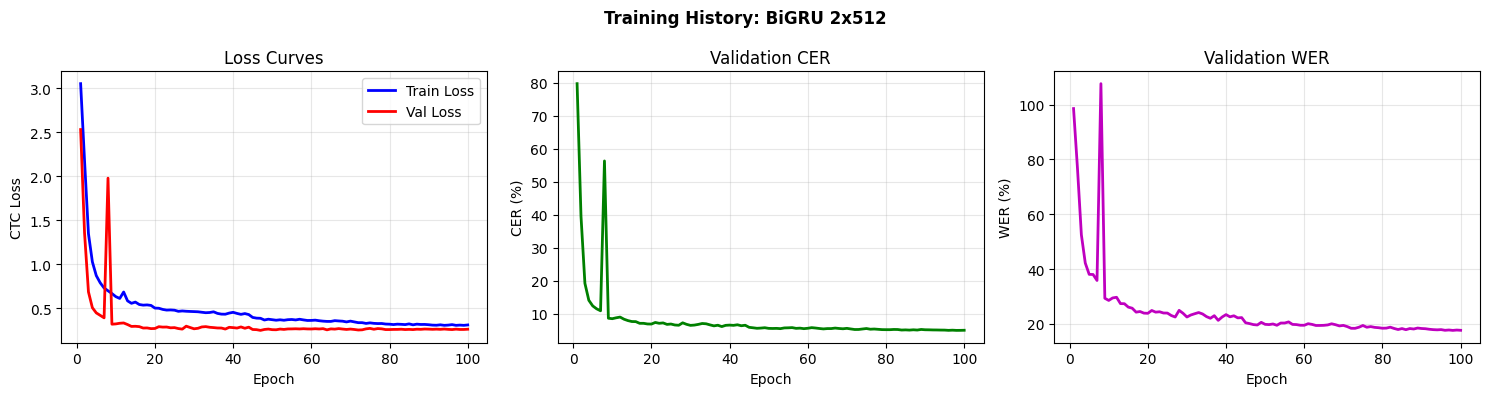

✅ BiGRU 2x512: Train-Val gap = -0.0486
------------------------------------------------------------


In [18]:
# ============================================
# ANALYZE TRAINING HISTORY (dari saved results)
# ============================================
# Jalankan ini untuk melihat training curves TANPA re-run experiments

def plot_training_history(experiment_dir: Path, show_overfit_warning: bool = True):
    """Plot training history dari saved JSON file"""
    history_file = experiment_dir / "training_history.json"
    config_file = experiment_dir / "config.json"
    
    if not history_file.exists():
        print(f"⚠️ No training history found in {experiment_dir.name}")
        return None
    
    with open(history_file, 'r') as f:
        history = json.load(f)
    
    exp_name = experiment_dir.name
    if config_file.exists():
        with open(config_file, 'r') as f:
            config = json.load(f)
            exp_name = config.get('experiment_name', experiment_dir.name)
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Training History: {exp_name}', fontsize=12, fontweight='bold')
    
    # Plot 1: Loss curves
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    if 'val_loss' in history and history['val_loss']:
        axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('CTC Loss')
    axes[0].set_title('Loss Curves')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: CER curve
    axes[1].plot(epochs, [c*100 for c in history['val_cer']], 'g-', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('CER (%)')
    axes[1].set_title('Validation CER')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: WER curve
    axes[2].plot(epochs, [w*100 for w in history['val_wer']], 'm-', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('WER (%)')
    axes[2].set_title('Validation WER')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Overfitting detection
    if show_overfit_warning and 'val_loss' in history and len(history['val_loss']) > 10:
        train_loss = history['train_loss']
        val_loss = history['val_loss']
        
        # Check last 10 epochs
        last_train = train_loss[-10:]
        last_val = val_loss[-10:]
        
        train_decreasing = last_train[-1] < last_train[0]
        val_increasing = last_val[-1] > last_val[0]
        
        if train_decreasing and val_increasing:
            print(f"⚠️ OVERFITTING DETECTED in {exp_name}!")
            print(f"   Train loss decreasing: {last_train[0]:.4f} → {last_train[-1]:.4f}")
            print(f"   Val loss increasing: {last_val[0]:.4f} → {last_val[-1]:.4f}")
        else:
            gap = val_loss[-1] - train_loss[-1]
            print(f"✅ {exp_name}: Train-Val gap = {gap:.4f}")
    
    return history


def analyze_all_experiments():
    """Analyze all experiments in EXPERIMENTS_DIR"""
    if not EXPERIMENTS_DIR.exists():
        print(f"❌ No experiments folder found: {EXPERIMENTS_DIR}")
        return
    
    exp_dirs = [d for d in EXPERIMENTS_DIR.iterdir() if d.is_dir() and (d / "training_history.json").exists()]
    
    if not exp_dirs:
        print("❌ No experiments with training history found.")
        print("   Run experiments first, or load previous results.")
        return
    
    print(f"📊 Found {len(exp_dirs)} experiments with training history\n")
    
    for exp_dir in sorted(exp_dirs):
        plot_training_history(exp_dir)
        print("-" * 60)


# Run analysis
print("📈 Training History Analysis")
print("="*60)
analyze_all_experiments()